# Library

In [16]:
from keras.src.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from keras.src.callbacks import CSVLogger, TensorBoard, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.applications.inception_v3 import InceptionV3
from keras.src.optimizers.schedules import CosineDecay, ExponentialDecay
from keras.src.metrics import Precision, Recall
from keras.src.utils import to_categorical
from keras.src.regularizers import L2
from keras.src.optimizers import Adam
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from collections import Counter
from keras import Sequential
import plotly.express as px
import seaborn as sns
import numpy as np
import warnings
import time
import glob
import cv2
import os

# PATH & Variable & Constants

In [17]:
warnings.filterwarnings('ignore')

VERSION = "v27"
BASE_DIR = "output"
DATASET_DIR = "dataset"
TRAIN_PATH = os.path.join(DATASET_DIR, "training")
TEST_PATH = os.path.join(DATASET_DIR, "testing")
VAL_PATH = os.path.join(DATASET_DIR, "validation")
PLOT_SAVE_DIR = os.path.join(BASE_DIR, "plot", VERSION)
LOG_DIR = os.path.join(BASE_DIR, "log", VERSION)
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "model", VERSION, "train.keras")
HISTORY_PATH = os.path.join(BASE_DIR, "model", VERSION, "train_history.npy")
CSV_LOGGER_PATH = os.path.join(LOG_DIR, "training_log.csv")
MISCLASSIFIED_DIR = os.path.join(BASE_DIR, "misclassified", VERSION)

IMAGE_SIZE = (299, 299)
INPUT_SHAPE = (299, 299, 3)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.0001
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LR = 0.00001

CLASS_NAMES = sorted([os.path.basename(d) for d in glob.glob(os.path.join(TRAIN_PATH, "*")) if os.path.isdir(d)])
NB_CLASSES = len(CLASS_NAMES)
LABEL_MAPPING = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

for directory in [PLOT_SAVE_DIR, LOG_DIR, os.path.dirname(MODEL_SAVE_PATH)]:
    os.makedirs(directory, exist_ok=True)

print(f"Model Version: {VERSION}")
print(f"Training Path: {TRAIN_PATH}")
print(f"Testing Path: {TEST_PATH}")
print(f"Validation Path: {VAL_PATH}")
print(f"{NB_CLASSES} Classes: {CLASS_NAMES}")

Model Version: v27
Training Path: dataset/training
Testing Path: dataset/testing
Validation Path: dataset/validation
4 Classes: ['alcohol', 'blood', 'sexual', 'traffic_accident']


# Load Data

In [18]:
def load_data(dataset, label_mapping, image_size=IMAGE_SIZE):
    images, labels = [], []
    for folder in os.listdir(dataset):
        folder_path = os.path.join(dataset, folder)
        if folder not in label_mapping or not os.path.isdir(folder_path):
            continue

        label = label_mapping[folder]
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(label)
    return np.array(images, dtype='float32'), np.array(labels, dtype='int')

# Execute images and labels

In [19]:
train_images, train_labels = load_data(TRAIN_PATH, LABEL_MAPPING)
test_images, test_labels = load_data(TEST_PATH, LABEL_MAPPING)
val_images, val_labels = load_data(VAL_PATH, LABEL_MAPPING)

In [20]:
train_labels = to_categorical(train_labels, num_classes=NB_CLASSES)
val_labels = to_categorical(val_labels, num_classes=NB_CLASSES)
test_labels = to_categorical(test_labels, num_classes=NB_CLASSES)

# Data Augmentation

In [21]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)

In [22]:
train_labels_int = np.argmax(train_labels, axis=1)
train_labels_list = train_labels_int.tolist()
class_counts = Counter(train_labels_list)
class_labels = [CLASS_NAMES[label] for label in class_counts.keys()]
counts = list(class_counts.values())

print("Class Counts Keys (should be integers 0-3):", list(class_counts.keys()))
print("Class Labels:", class_labels)
print("Counts:", counts)

Class Counts Keys (should be integers 0-3): [3, 1, 2, 0]
Class Labels: ['traffic_accident', 'blood', 'sexual', 'alcohol']
Counts: [800, 800, 800, 800]


# Visualize dataset

In [23]:
fig = px.bar(
    x=class_labels,
    y=counts,
    template='plotly_dark',
    color=class_labels,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'},
    text=counts
)

fig.update_layout(
    xaxis_title='Class Label',
    yaxis_title='Count of Images',
    showlegend=False
)

fig.show()
print("Class Distribution Plotted")

Class Distribution Plotted


In [24]:
val_labels_int = np.argmax(val_labels, axis=1)
test_labels_int = np.argmax(test_labels, axis=1)

train_counter = Counter(train_labels_int)
val_counter = Counter(val_labels_int)
test_counter = Counter(test_labels_int)

train_counts = [train_counter.get(i, 0) for i in range(NB_CLASSES)]
val_counts = [val_counter.get(i, 0) for i in range(NB_CLASSES)]
test_counts = [test_counter.get(i, 0) for i in range(NB_CLASSES)]

fig = go.Figure()

# Train Data
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=train_counts,
    name='Train',
    marker=dict(color='blue'),
    text=train_counts,
    textposition='auto'
))

# Validation Data
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=val_counts,
    name='Validation',
    marker=dict(color='green'),
    text=val_counts,
    textposition='auto'
))

# Test Data
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=test_counts,
    name='Test',
    marker=dict(color='red'),
    text=test_counts,
    textposition='auto'
))

# Layout
fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark",
    xaxis=dict(tickangle=-45)
)

fig.show()

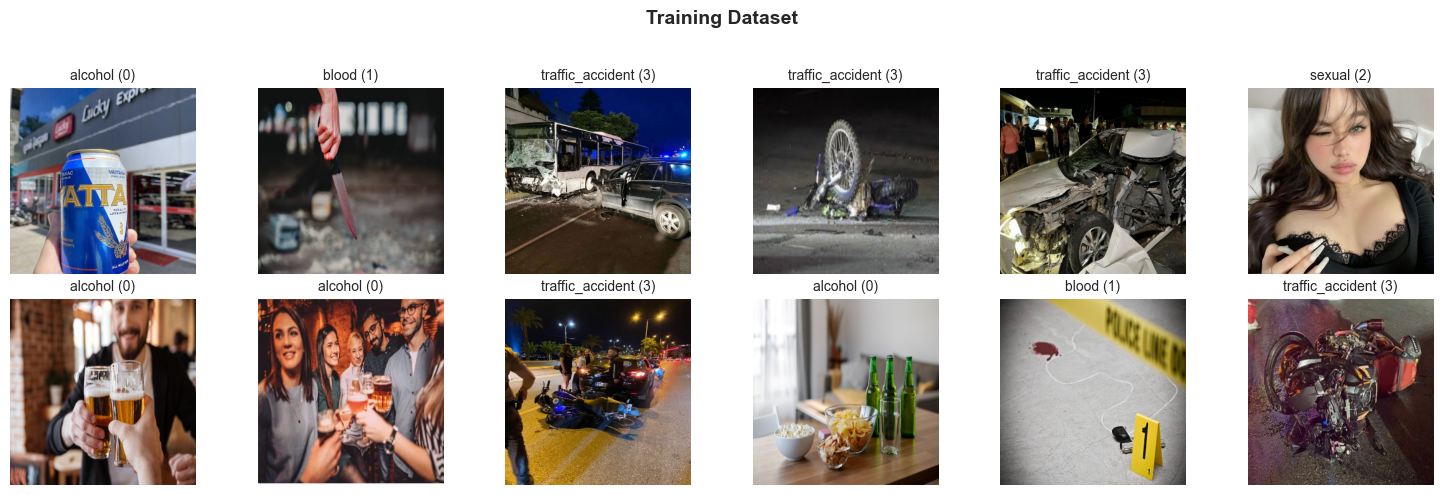

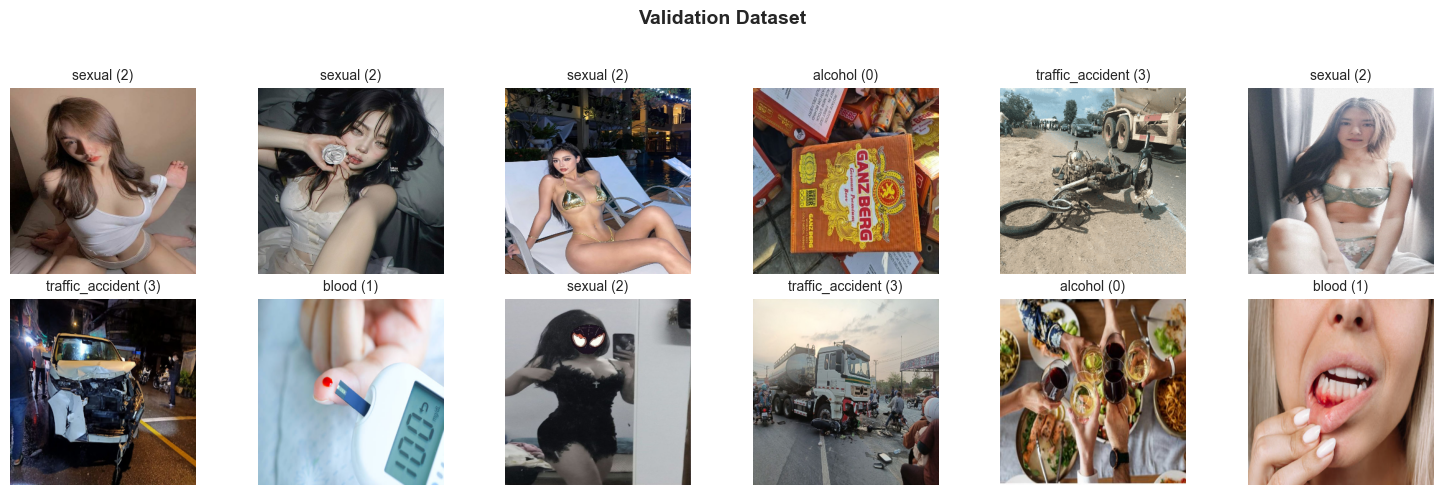

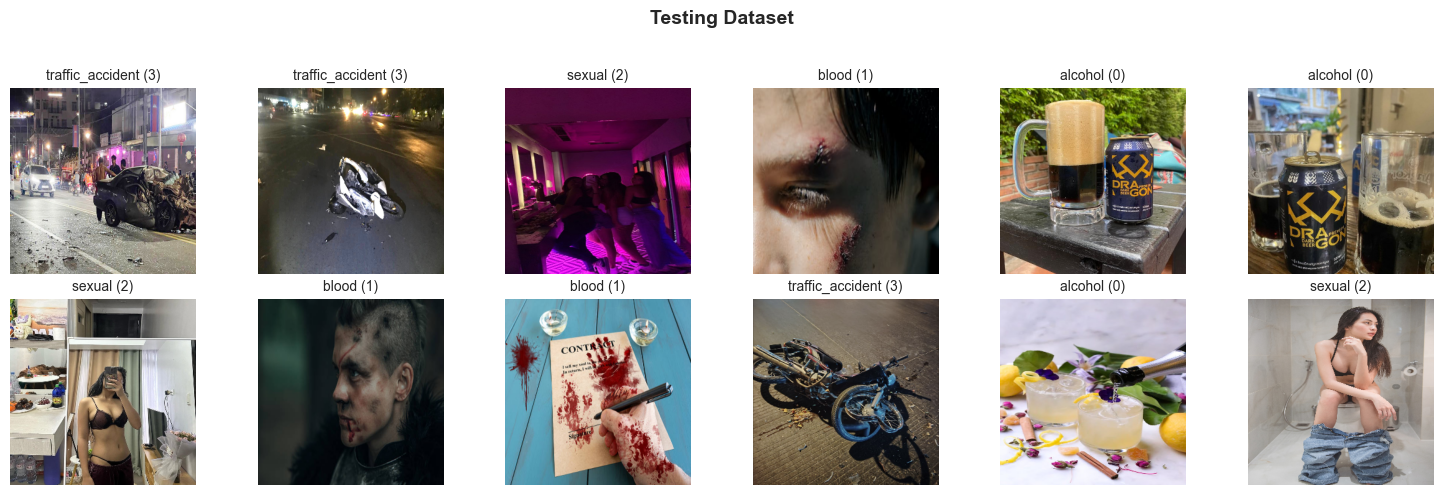

In [25]:
def display_dataset(class_names, images, labels, dataset_type, num_images=12):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)

    cols = 6
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(15, 15 * rows / cols), facecolor="none")
    plt.suptitle(f"{dataset_type} Dataset", fontsize=14, fontweight='bold')

    for i, idx in enumerate(random_indices):
        image = images[idx]
        label = labels[idx]

        if labels.ndim > 1:
            label = np.argmax(label)
        class_name = class_names[label]

        if image.dtype != np.uint8:
            image = image.astype(np.uint8)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(f"{class_name} ({label})", fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


display_dataset(CLASS_NAMES, train_images, train_labels, "Training")

display_dataset(CLASS_NAMES, val_images, val_labels, "Validation")

display_dataset(CLASS_NAMES, test_images, test_labels, "Testing")

# Model architecture

In [38]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu", kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation="relu", kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation="relu", kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(NB_CLASSES, activation="softmax")
])

optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_191         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_192         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_193         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,020,196 (87.82 MB)

 Trainable params: 1,215,620 (4.64 MB)

 Non-trainable params: 21,804,576 (83.18 MB)

# Plotting History

In [27]:
def plot_training_history(history, phase_name="training"):
    epochs = range(1, len(history.history.get('accuracy', [])) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history and 'val_accuracy' in history.history:
        plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', marker='o')
        plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{phase_name} & Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    if 'loss' in history.history and 'val_loss' in history.history:
        plt.plot(epochs, history.history['loss'], label='Train Loss', marker='o')
        plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{phase_name} & Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    plot_path = os.path.join(PLOT_SAVE_DIR, f"{phase_name.lower()}_history.png")
    plt.savefig(plot_path)
    plt.show()
    print(f"{phase_name} history plot saved at: {plot_path}")

# Compile the model

Starting Training...
Epoch 1/30

Epoch 1: val_loss improved from inf to 1.86111, saving model to output/model/v27/train.keras
100/100 - 157s - 2s/step - accuracy: 0.7197 - loss: 2.0621 - precision: 0.7752 - recall: 0.6672 - val_accuracy: 0.9050 - val_loss: 1.8611 - val_precision: 0.9866 - val_recall: 0.7375
Epoch 2/30

Epoch 2: val_loss improved from 1.86111 to 1.53396, saving model to output/model/v27/train.keras
100/100 - 151s - 2s/step - accuracy: 0.9047 - loss: 1.5954 - precision: 0.9195 - recall: 0.8894 - val_accuracy: 0.9475 - val_loss: 1.5340 - val_precision: 0.9634 - val_recall: 0.9225
Epoch 3/30

Epoch 3: val_loss improved from 1.53396 to 1.42986, saving model to output/model/v27/train.keras
100/100 - 148s - 1s/step - accuracy: 0.9262 - loss: 1.5378 - precision: 0.9370 - recall: 0.9159 - val_accuracy: 0.9750 - val_loss: 1.4299 - val_precision: 0.9821 - val_recall: 0.9575
Epoch 4/30

Epoch 4: val_loss improved from 1.42986 to 1.39618, saving model to output/model/v27/train.kera

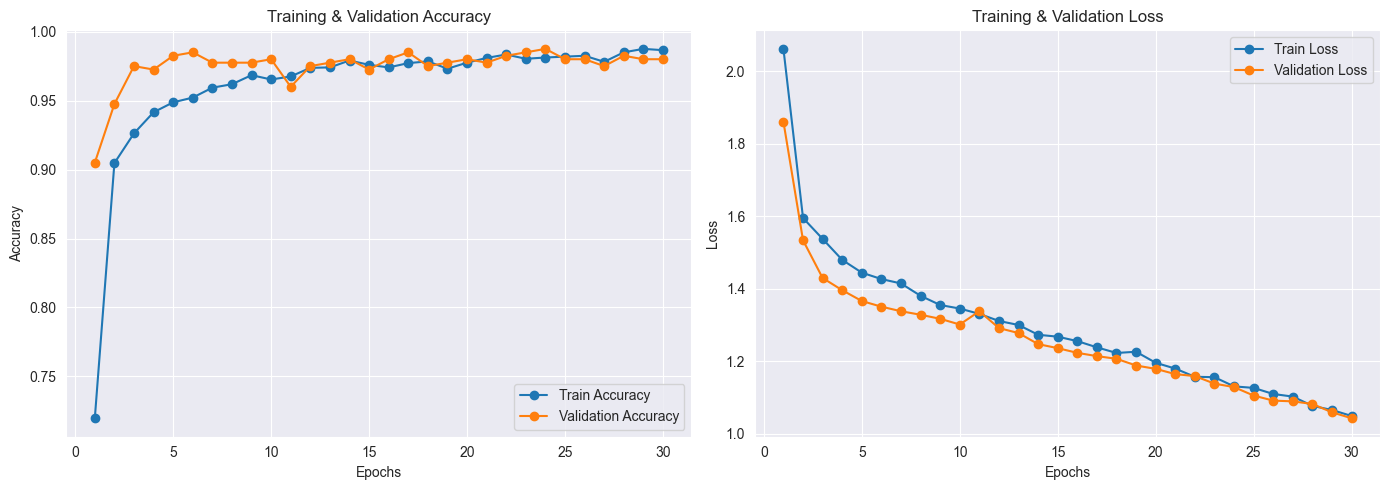

Training history plot saved at: output/plot/v27/training_history.png


In [28]:
callbacks = [
    CSVLogger(CSV_LOGGER_PATH, append=False),
    TensorBoard(log_dir=LOG_DIR, histogram_freq=1),
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

lr_schedule_phase_1 = CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=10000,
    alpha=1e-6
)

# Phase 1: Initial Training
print("Starting Training...")
start_time = time.time()

model.compile(optimizer=Adam(learning_rate=lr_schedule_phase_1),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

print(f"Training time (sec): {time.time() - start_time}")
model.save(MODEL_SAVE_PATH)
np.save(HISTORY_PATH, history.history)
print("Training Complete!")
plot_training_history(history, phase_name="Training")

Starting Fine-Tuning...
Epoch 1/20

Epoch 1: val_loss did not improve from 1.04279
100/100 - 3393s - 34s/step - accuracy: 0.9450 - loss: 1.1609 - precision: 0.9502 - recall: 0.9416 - val_accuracy: 0.9900 - val_loss: 1.0501 - val_precision: 0.9900 - val_recall: 0.9875
Epoch 2/20

Epoch 2: val_loss improved from 1.04279 to 1.03348, saving model to output/model/v27/train.keras
100/100 - 646s - 6s/step - accuracy: 0.9653 - loss: 1.0864 - precision: 0.9677 - recall: 0.9634 - val_accuracy: 0.9850 - val_loss: 1.0335 - val_precision: 0.9850 - val_recall: 0.9825
Epoch 3/20

Epoch 3: val_loss improved from 1.03348 to 1.02562, saving model to output/model/v27/train.keras
100/100 - 610s - 6s/step - accuracy: 0.9744 - loss: 1.0530 - precision: 0.9768 - recall: 0.9716 - val_accuracy: 0.9850 - val_loss: 1.0256 - val_precision: 0.9850 - val_recall: 0.9850
Epoch 4/20

Epoch 4: val_loss improved from 1.02562 to 1.01313, saving model to output/model/v27/train.keras
100/100 - 608s - 6s/step - accuracy: 0.

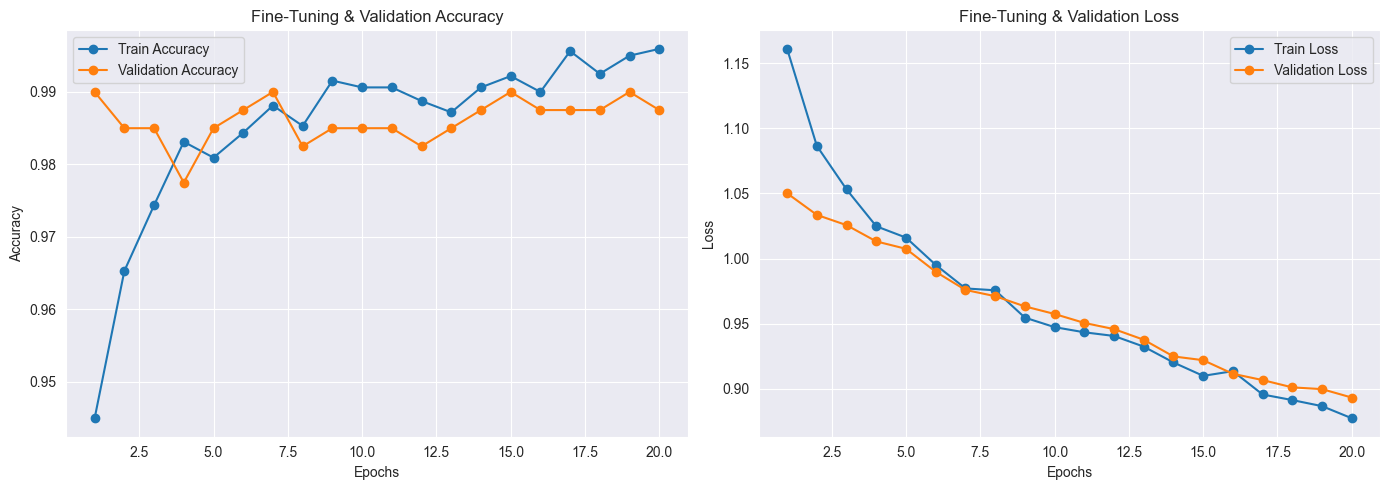

Fine-Tuning history plot saved at: output/plot/v27/fine-tuning_history.png


In [29]:
lr_schedule_phase_2 = ExponentialDecay(
    initial_learning_rate=FINE_TUNE_LR,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

# Phase 2: Fine-Tuning
print("Starting Fine-Tuning...")
start_time = time.time()

base_model.trainable = True
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=lr_schedule_phase_2),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

fine_tune_history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=2
)

print(f"Fine-tuning time (sec): {time.time() - start_time}")

fine_tuned_model_path = MODEL_SAVE_PATH.replace(".keras", "_fine_tuned.keras")
fine_tuned_history_path = HISTORY_PATH.replace(".npy", "_fine_tuned.npy")
model.save(fine_tuned_model_path)
np.save(fine_tuned_history_path, fine_tune_history.history)

print("Fine-Tuning Complete!")
plot_training_history(fine_tune_history, phase_name="Fine-Tuning")

# Evaluate the model

In [30]:
# Confusion matrix 
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plot_path = os.path.join(PLOT_SAVE_DIR, "confusion_matrix.png")
    plt.savefig(plot_path)
    plt.show()
    print(f"✅ Confusion matrix saved at: {plot_path}")

Evaluating on Test Set...
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9859 - loss: 0.9140 - precision: 0.9859 - recall: 0.9859
Test Accuracy: 0.9800000190734863, Precision: 0.9800000190734863, Recall: 0.9800000190734863
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step

📊 Classification Report (dict):
{'alcohol': {'precision': 0.9611650485436893, 'recall': 0.99, 'f1-score': 0.9753694581280788, 'support': 100.0}, 'blood': {'precision': 0.9696969696969697, 'recall': 0.96, 'f1-score': 0.964824120603015, 'support': 100.0}, 'sexual': {'precision': 0.9897959183673469, 'recall': 0.97, 'f1-score': 0.9797979797979798, 'support': 100.0}, 'traffic_accident': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 100.0}, 'accuracy': 0.98, 'macro avg': {'precision': 0.9801644841520015, 'recall': 0.98, 'f1-score': 0.9799978896322684, 'support': 400.0}, 'weighted avg': {'precision': 0.9801644841520016, 'recall': 0.98, 'f1-score': 0.9799978896322685, 'support': 400.0}}


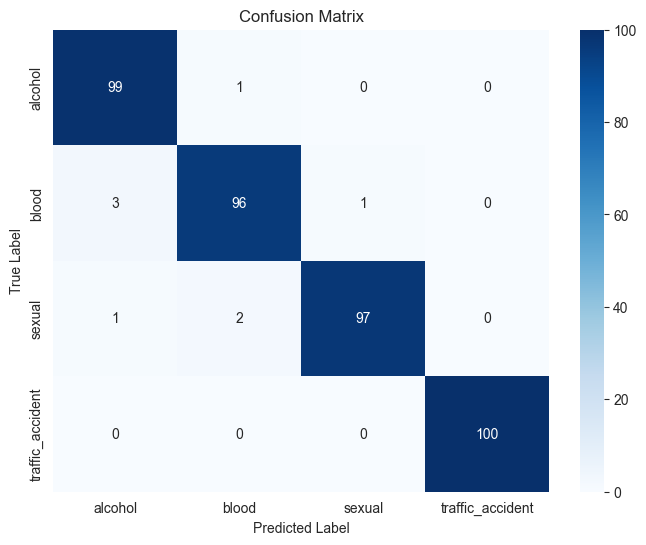

✅ Confusion matrix saved at: output/plot/v27/confusion_matrix.png
Misclassified indices: [114 179 195 196 203 244 257 383]
Failed to save image: output/misclassified/v27/true_blood_pred_alcohol_114.png
Failed to save image: output/misclassified/v27/true_blood_pred_sexual_179.png
Failed to save image: output/misclassified/v27/true_blood_pred_alcohol_195.png
Failed to save image: output/misclassified/v27/true_blood_pred_alcohol_196.png
Failed to save image: output/misclassified/v27/true_sexual_pred_blood_203.png
Failed to save image: output/misclassified/v27/true_sexual_pred_blood_244.png
Failed to save image: output/misclassified/v27/true_sexual_pred_alcohol_257.png
Failed to save image: output/misclassified/v27/true_alcohol_pred_blood_383.png
Misclassified images saved at: output/misclassified/v27


In [31]:
print("Evaluating on Test Set...")
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc}, Precision: {test_prec}, Recall: {test_rec}")

predictions = model.predict(test_generator)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Classification Report
class_report = classification_report(true_labels, pred_labels, target_names=CLASS_NAMES, output_dict=True)
print(f"\n📊 Classification Report (dict):\n{class_report}")
with open(os.path.join(LOG_DIR, "classification_report.txt"), 'w') as f:
    f.write(str(class_report))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
cm_path = os.path.join(PLOT_SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path)
plt.show()
print(f"✅ Confusion matrix saved at: {cm_path}")

# Save Misclassified Images
misclassified_idx = np.where(pred_labels != true_labels)[0]
print(f"Misclassified indices: {misclassified_idx}")

test_images_scaled = (test_images * 255).clip(0, 255)

for idx in misclassified_idx:
    img = test_images_scaled[idx].astype(np.uint8)
    true_label = CLASS_NAMES[true_labels[idx]]
    pred_label = CLASS_NAMES[pred_labels[idx]]
    filename = f"true_{true_label}_pred_{pred_label}_{idx}.png"
    file_path = str(os.path.join(MISCLASSIFIED_DIR, filename))
    success = cv2.imwrite(file_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    if not success:
        print(f"Failed to save image: {file_path}")
print(f"Misclassified images saved at: {MISCLASSIFIED_DIR}")

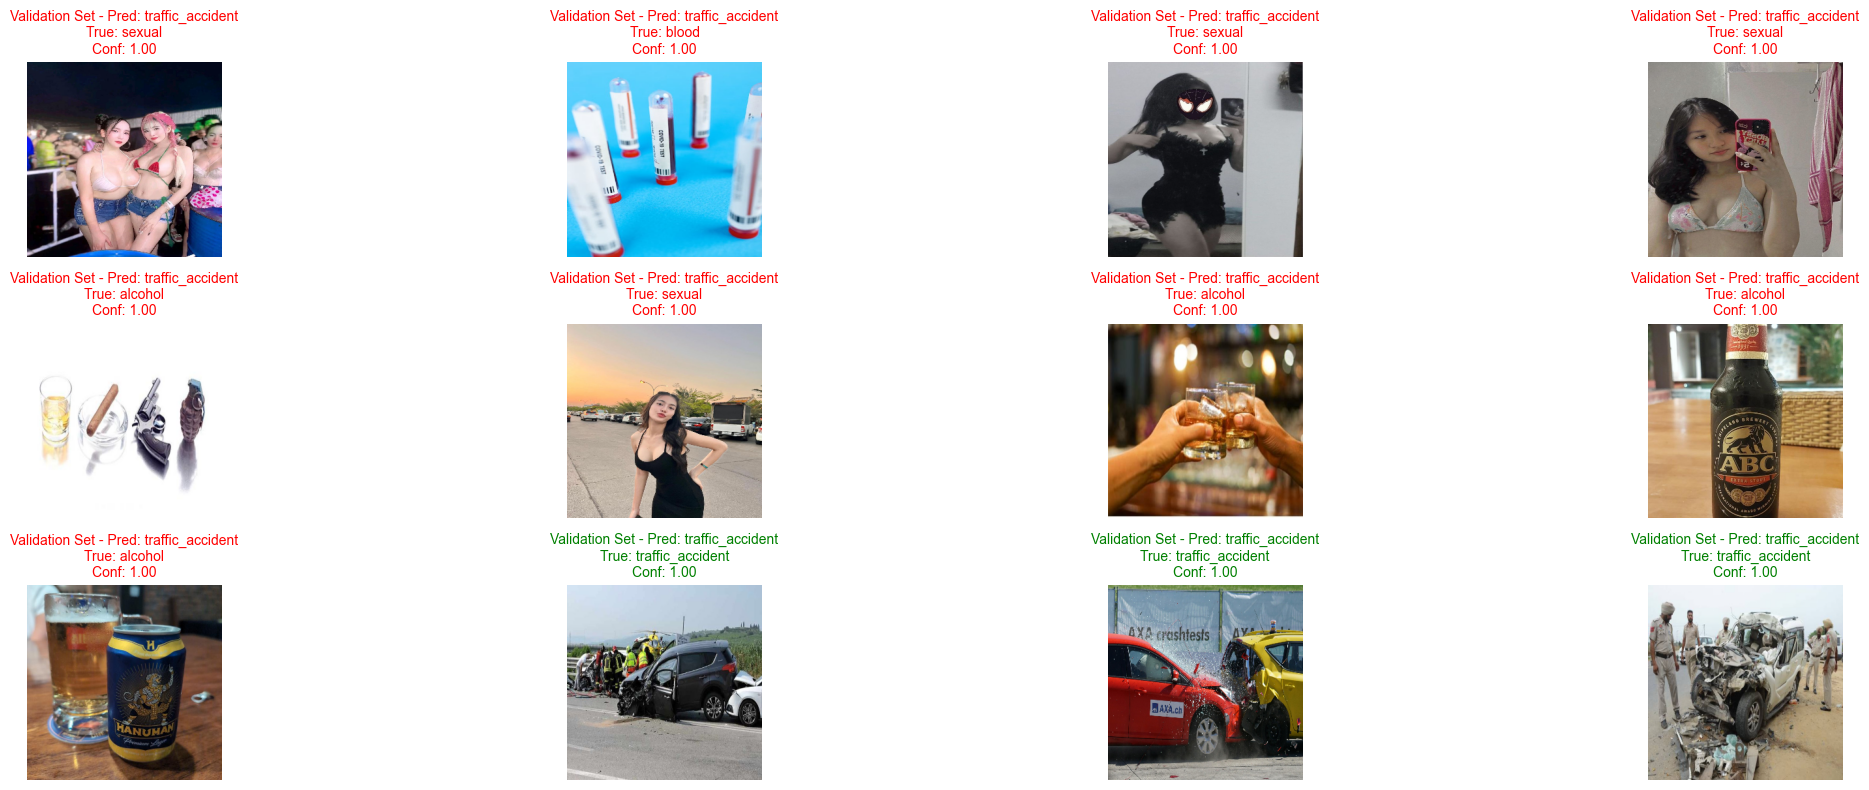

Sample predictions saved at: output/plot/v27/validation_sample_predictions.png


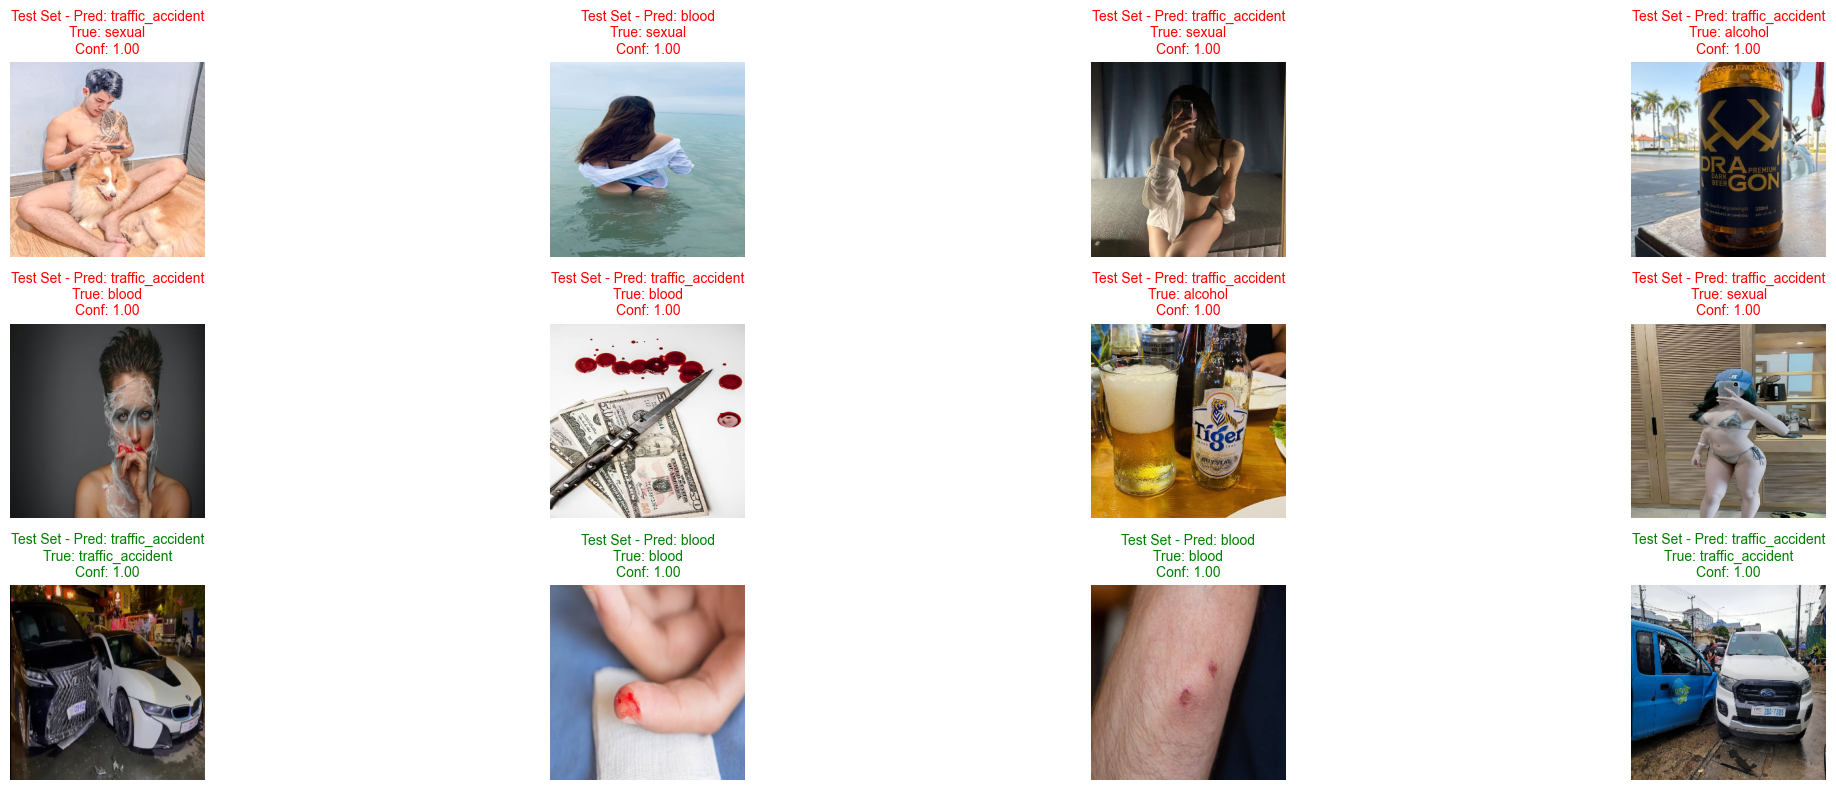

Sample predictions saved at: output/plot/v27/test_sample_predictions.png


In [37]:
def display_sample_predictions(model, class_names, images, labels, set_name="Sample", num_images=12,
                               confidence_threshold=0.8):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)

    plt.figure(figsize=(num_images * 2, 8))

    misclassified = []
    correct = []

    for idx in random_indices:
        image = images[idx]
        true_label = np.argmax(labels[idx])
        img_input = np.expand_dims(image, axis=0)
        prediction = model.predict(img_input, verbose=0)
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        if confidence >= confidence_threshold:
            if predicted_label == true_label:
                correct.append((idx, confidence))
            else:
                misclassified.append((idx, confidence))

    sorted_indices = [i[0] for i in sorted(misclassified + correct, key=lambda x: x[1], reverse=True)]

    cols = min(num_images, 4)
    rows = (num_images + cols - 1) // cols

    for i, idx in enumerate(sorted_indices[:num_images]):
        image = images[idx]
        true_label = np.argmax(labels[idx])
        img_input = np.expand_dims(image, axis=0)
        prediction = model.predict(img_input, verbose=0)
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.astype(np.uint8))
        plt.axis('off')

        title_color = "green" if predicted_label == true_label else "red"
        plt.title(f"{set_name} Set - Pred: {class_names[predicted_label]}\n"
                  f"True: {class_names[true_label]}\n"
                  f"Conf: {confidence:.2f}",
                  fontsize=10, color=title_color)

    plt.tight_layout()
    save_path = os.path.join(PLOT_SAVE_DIR, f"{set_name.lower()}_sample_predictions.png")
    plt.savefig(save_path)
    plt.show()
    print(f"Sample predictions saved at: {save_path}")


display_sample_predictions(model, CLASS_NAMES, val_images, val_labels, set_name="Validation")
display_sample_predictions(model, CLASS_NAMES, test_images, test_labels, set_name="Test")

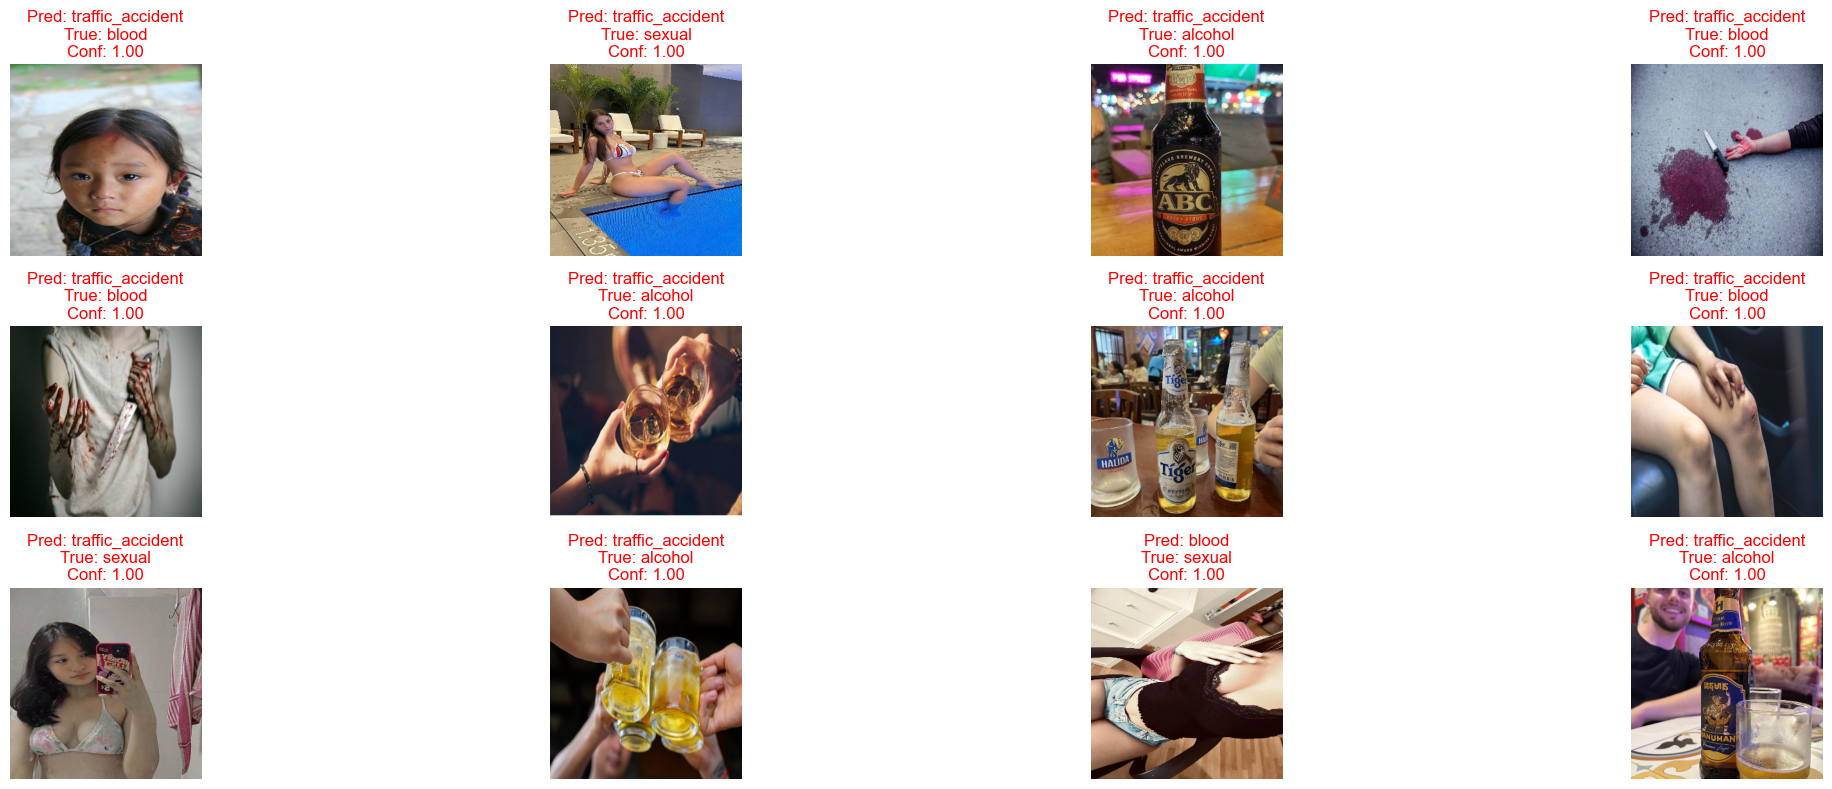

Misclassifications saved at: output/plot/v27/misclassifications.png


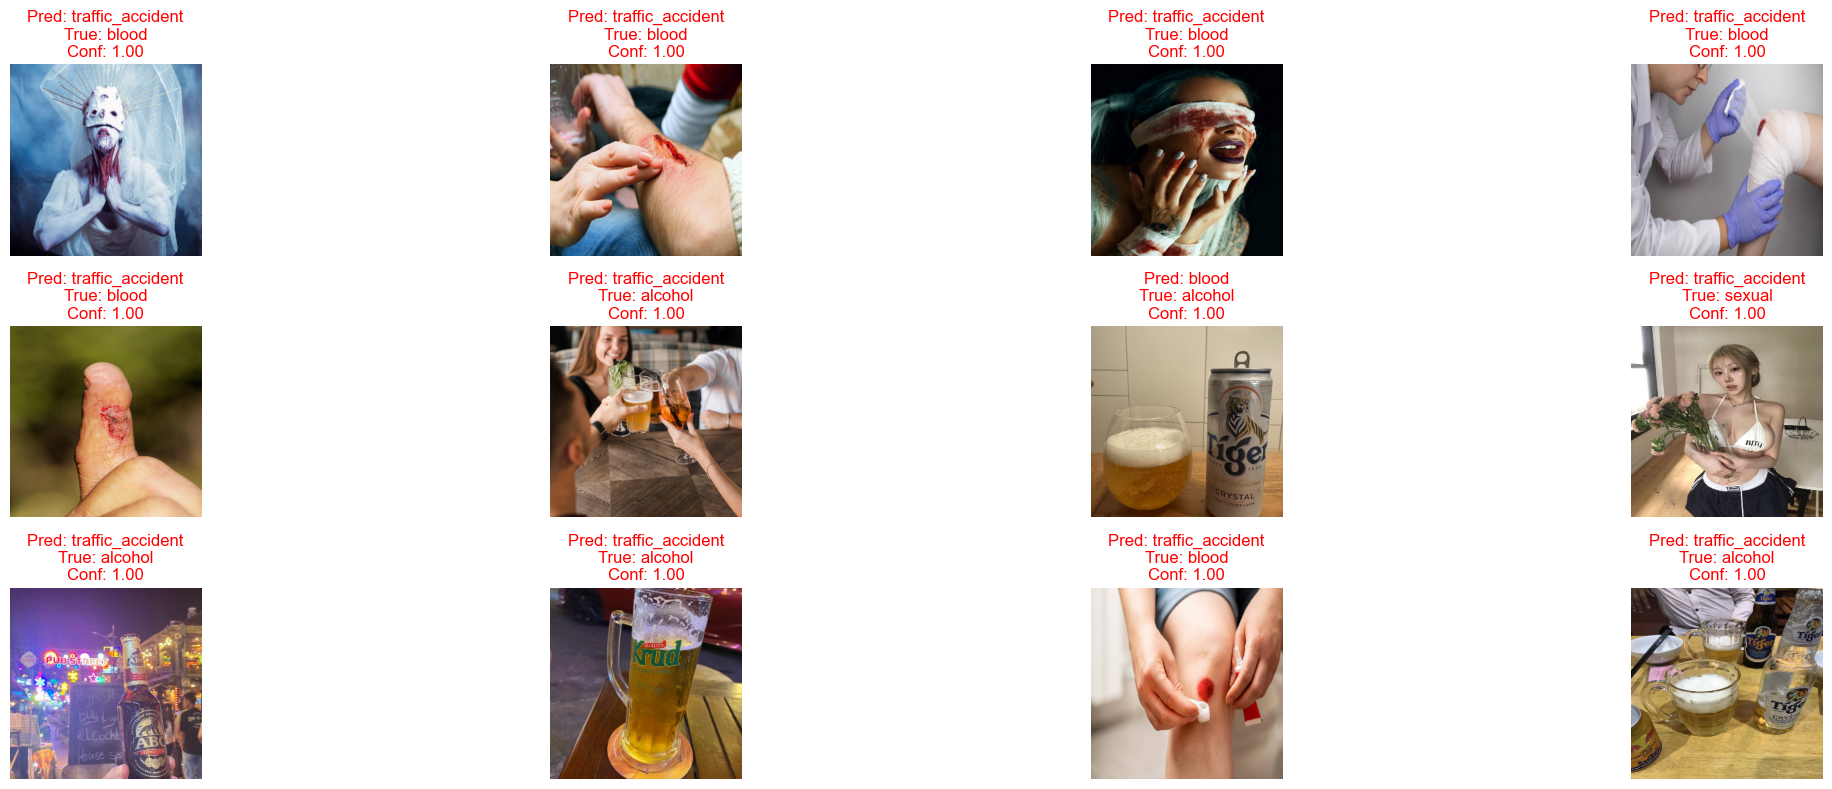

Misclassifications saved at: output/plot/v27/misclassifications.png


In [34]:
def display_misclassifications(model, class_names, images, labels, num_images=12):
    y_pred = np.argmax(model.predict(images, verbose=0), axis=1)
    y_true = np.argmax(labels, axis=1)
    misclassified_indices = np.where(y_pred != y_true)[0]
    if len(misclassified_indices) == 0:
        print("No misclassifications found!")
        return
    random_indices = np.random.choice(misclassified_indices, min(num_images, len(misclassified_indices)), replace=False)
    plt.figure(figsize=(num_images * 2, 8))
    for i, idx in enumerate(random_indices[:num_images]):
        image = images[idx]
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        confidence = np.max(model.predict(np.expand_dims(image, axis=0), verbose=0))
        plt.subplot(3, 4, i + 1)
        plt.imshow(image.astype(np.uint8))
        plt.axis('off')
        plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}\nConf: {confidence:.2f}",
                  color='red')
    plt.tight_layout()
    save_path = os.path.join(PLOT_SAVE_DIR, "misclassifications.png")
    plt.savefig(save_path)
    plt.show()
    print(f"Misclassifications saved at: {save_path}")


display_misclassifications(model, CLASS_NAMES, val_images, val_labels)
display_misclassifications(model, CLASS_NAMES, test_images, test_labels)